In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [ ]:
# ---------------------------
# 1) Preparing the data
# ---------------------------

def make_spirals(n_samples=2000, noise=0.2):
    n = np.sqrt(np.random.rand(n_samples,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_samples,1)*noise
    d1y =  np.sin(n)*n + np.random.rand(n_samples,1)*noise
    X = np.vstack((np.hstack((d1x,d1y)), 
                   np.hstack((-d1x,-d1y))))
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
    return X.astype(np.float32), y.astype(np.int64)

X, y = make_spirals()

# seperate train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [10]:
# ---------------------------
# 2) Fuzzy C-Means for Initialization
# ---------------------------

def fcm_initialize(X, K, m=2.0):
    """
    X: numpy array shape (N, n_inputs)
    K: number of clusters / rules
    Returns:
        centers: (K, n_inputs)
        spreads: (K, n_inputs)
    """
    X_t = X.T  # (n_inputs, N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    N = X.shape[0]

    spreads = []
    for k in range(K):
        weights = u[k].reshape(N, 1)   # (N,1)
        diff = X - cntr[k]             # (N, n_inputs)
        denom = np.sum(weights) + 1e-12
        var = np.sum(weights * (diff ** 2), axis=0) / denom
        spreads.append(np.sqrt(var))
    spreads = np.array(spreads)
    spreads = np.clip(spreads, 1e-3, None)
    return np.array(cntr), spreads


In [11]:
class GaussianSigmoidMF(nn.Module):
    def __init__(self, centers_init, spreads_init, s_mode="C", eps_s=1e-12):
        super().__init__()
        # allow numpy or torch inputs; store as torch parameters
        self.K = int(centers_init.shape[0])
        self.n_inputs = int(centers_init.shape[1])
        self.s_mode = s_mode
        self.eps_s = eps_s

        # convert to tensors if needed and register as parameters
        centers_t = torch.tensor(centers_init, dtype=torch.float32) if not torch.is_tensor(centers_init) else centers_init.float()
        spreads_t = torch.tensor(spreads_init, dtype=torch.float32) if not torch.is_tensor(spreads_init) else spreads_init.float()

        self.c = nn.Parameter(centers_t)   # (K, n_inputs)
        self.s = nn.Parameter(spreads_t)   # raw spreads (K, n_inputs)

        # blending params
        if s_mode == "C":
            self.C = nn.Parameter(torch.zeros(self.K, self.n_inputs, dtype=torch.float32))
        elif s_mode == "alpha_beta":
            self.alpha = nn.Parameter(torch.ones(self.K, self.n_inputs, dtype=torch.float32))
            self.beta  = nn.Parameter(torch.ones(self.K, self.n_inputs, dtype=torch.float32))
        else:
            raise ValueError("s_mode must be 'C' or 'alpha_beta'")

    def forward(self, x):
        """
        x: (batch, n_inputs)
        returns: w (batch, K)  -- firing strengths (product across inputs)
        """
        batch = x.shape[0]

        # enforce positive spreads
        s_pos = torch.nn.functional.softplus(self.s) + 1e-6   # (K, n_inputs)

        # broadcasting to (batch, K, n_inputs)
        x_exp = x.unsqueeze(1).expand(batch, self.K, self.n_inputs)
        c_exp = self.c.unsqueeze(0).expand(batch, self.K, self.n_inputs)
        s_exp = s_pos.unsqueeze(0).expand(batch, self.K, self.n_inputs)

        # Gaussian MF: exp(- (x-c)^2 / (2 s^2) )
        mu_gauss = torch.exp(- ((x_exp - c_exp) ** 2) / (2.0 * (s_exp ** 2) + 1e-12))

        # Sigmoid MF (form B you requested): sigmoid( (x - c) / s )
        mu_sig = torch.sigmoid((x_exp - c_exp) / (s_exp + 1e-12))

        # Blending factor s_ij
        if self.s_mode == "C":
            blend_s = torch.sigmoid(self.C)  # (K, n_inputs)
        else:
            alpha2 = self.alpha ** 2
            beta2  = self.beta ** 2
            blend_s = alpha2 / (alpha2 + beta2 + self.eps_s)  # (K, n_inputs)

        blend_s_exp = blend_s.unsqueeze(0).expand(batch, self.K, self.n_inputs)

        # blended MF per input
        mu_blend = blend_s_exp * mu_gauss + (1.0 - blend_s_exp) * mu_sig  # (batch, K, n_inputs)

        # firing strengths: product across input dims
        w = torch.prod(mu_blend, dim=2)  # (batch, K)

        return w

In [12]:
# ---------------------------
# 4) ANFIS using the blended MF
# ---------------------------
class ANFIS_BlendMF(nn.Module):
    def __init__(self, centers_init, spreads_init, s_mode="C"):
        super().__init__()
        # Ensure centers/spreads are numpy/torch-compatible shapes
        self.K = int(centers_init.shape[0])
        self.n_inputs = int(centers_init.shape[1])

        # fuzzy layer
        self.mf_layer = GaussianSigmoidMF(centers_init, spreads_init, s_mode=s_mode)

        # linear consequents: each rule has weights (n_inputs) and bias -> (K, n_inputs+1)
        self.consequents = nn.Parameter(torch.randn(self.K, self.n_inputs + 1) * 0.1)

    def forward(self, x):
        # x: (batch, n_inputs)
        batch = x.shape[0]

        # 1) firing strengths
        w = self.mf_layer(x)  # (batch, K)
        w = torch.clamp(w, min=1e-8)   # numerical stability
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum             # (batch, K)

        # 2) linear consequents per rule
        x_exp = x.unsqueeze(1).expand(-1, self.K, -1)  # (batch, K, n_inputs)
        cons_w = self.consequents[:, :-1].unsqueeze(0) # (1, K, n_inputs)
        linear_part = torch.sum(x_exp * cons_w, dim=2) # (batch, K)
        bias = self.consequents[:, -1].unsqueeze(0)    # (1, K)
        y_r = linear_part + bias                       # (batch, K)

        # 3) weighted aggregation → final logit
        logit = torch.sum(w_norm * y_r, dim=1, keepdim=True)  # (batch, 1)

        return logit   # return logits (do NOT sigmoid here)


In [13]:
# ---------------------------
# 5) Training (Classification)
# ---------------------------

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert labels to float for BCE
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor = torch.from_numpy(X_train).to(device)
X_test_tensor  = torch.from_numpy(X_test).to(device)

# ---------------------------
# Initialization via FCM
# ---------------------------
K = 6
centers_init, spreads_init = fcm_initialize(X_train, K)

# ---------------------------
# Model setup
# ---------------------------
s_mode_choice = "alpha_beta"   # or "C"
model = ANFIS_BlendMF(centers_init, spreads_init, s_mode=s_mode_choice).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# IMPORTANT: logits → use BCEWithLogitsLoss (sigmoid inside)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward
    logits_train = model(X_train_tensor)   # raw logits

    # Loss
    loss = loss_fn(logits_train, y_train_tensor)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Track best
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Progress
    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_log = model(X_train_tensor)
            test_log  = model(X_test_tensor)

            # Convert to probabilities for RMSE (sigmoid)
            train_prob = torch.sigmoid(train_log)
            test_prob  = torch.sigmoid(test_log)

            train_rmse = torch.sqrt(torch.mean((train_prob - y_train_tensor)**2)).item()
            test_rmse  = torch.sqrt(torch.mean((test_prob  - y_test_tensor )**2)).item()

        print(f"Epoch {epoch}/{n_epochs}  Loss: {loss.item():.4f}  "
              f"Train RMSE: {train_rmse:.4f}  Test RMSE: {test_rmse:.4f}")

# ---------------------------
# Restore best params
# ---------------------------
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

# ---------------------------
# Final evaluation
# ---------------------------
with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits  = model(X_test_tensor)

    final_train_prob = torch.sigmoid(final_train_logits).cpu().numpy().reshape(-1)
    final_test_prob  = torch.sigmoid(final_test_logits ).cpu().numpy().reshape(-1)

train_rmse = np.sqrt(np.mean((final_train_prob - y_train)**2))
test_rmse  = np.sqrt(np.mean((final_test_prob  - y_test )**2))

print("\nFinal Results:")
print("Mode:", s_mode_choice)
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")


Epoch 1/1000  Loss: 0.7219  Train RMSE: 0.5133  Test RMSE: 0.5155
Epoch 100/1000  Loss: 0.6623  Train RMSE: 0.4854  Test RMSE: 0.4796
Epoch 200/1000  Loss: 0.6450  Train RMSE: 0.4771  Test RMSE: 0.4696
Epoch 300/1000  Loss: 0.6324  Train RMSE: 0.4714  Test RMSE: 0.4633
Epoch 400/1000  Loss: 0.6222  Train RMSE: 0.4670  Test RMSE: 0.4591
Epoch 500/1000  Loss: 0.6131  Train RMSE: 0.4634  Test RMSE: 0.4560
Epoch 600/1000  Loss: 0.6052  Train RMSE: 0.4603  Test RMSE: 0.4537
Epoch 700/1000  Loss: 0.5989  Train RMSE: 0.4580  Test RMSE: 0.4519
Epoch 800/1000  Loss: 0.5940  Train RMSE: 0.4561  Test RMSE: 0.4504
Epoch 900/1000  Loss: 0.5900  Train RMSE: 0.4546  Test RMSE: 0.4491
Epoch 1000/1000  Loss: 0.5864  Train RMSE: 0.4531  Test RMSE: 0.4479

Final Results:
Mode: alpha_beta
Train RMSE: 0.4531
Test RMSE : 0.4479


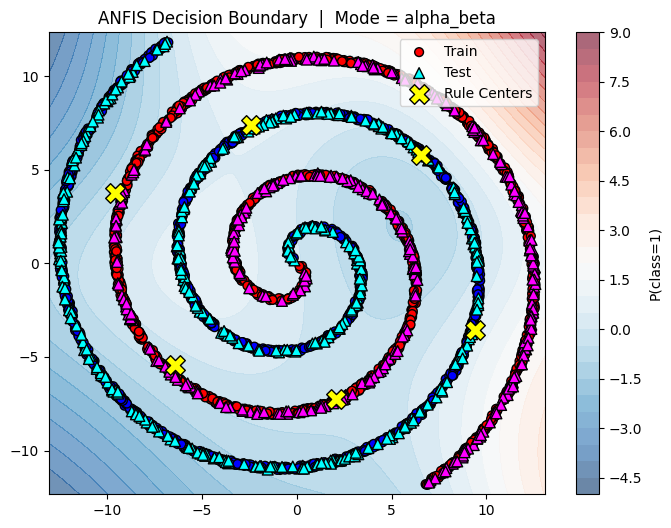

In [14]:
    # ---------------------------
    # 7: Plot decision boundary
    # ---------------------------
    plt.figure(figsize=(8, 6))
    
    # Grid for visualization
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_tensor = torch.from_numpy(grid).to(device)
    
    with torch.no_grad():
        prob_grid = model(grid_tensor).cpu().numpy().reshape(xx.shape)
    
    # Decision boundary contour
    contour = plt.contourf(xx, yy, prob_grid, levels=30, cmap="RdBu_r", alpha=0.6)
    plt.colorbar(contour, label="P(class=1)")
    
    # Training data
    plt.scatter(
        X_train[:, 0], X_train[:, 1], 
        c=y_train, cmap="bwr", edgecolor="k", s=40, label="Train"
    )
    
    # Test data
    plt.scatter(
        X_test[:, 0], X_test[:, 1], 
        c=y_test, cmap="cool", edgecolor="k", s=60, marker="^", label="Test"
    )
    
    # Optional: show rule centers
    plt.scatter(
        centers_init[:, 0], centers_init[:, 1],
        c="yellow", s=200, edgecolor="black", marker="X",
        label="Rule Centers"
    )
    
    plt.title(f"ANFIS Decision Boundary  |  Mode = {s_mode_choice}")
    plt.legend()
    plt.show()
